## 9. Key Findings & Conclusions

### ❌ Threshold variants do NOT improve cluster quality

All 5 threshold-based formulas (M1–M5) produce **worse** visual separation than the baseline M0 (no threshold), despite some achieving higher silhouette scores on the metrics table.

#### Root cause

The fundamental issue is **not** which function combines Totalmenge and Threshold — it is that **adding threshold at all collapses PCA variance onto one dominant axis**:

1. Ingredients with very low threshold ppm (e.g. 0.001 ppm) receive enormous weight factors (1/T = 1000×), dwarfing all others regardless of actual quantity.
2. After L2-normalisation, the per-family signal becomes near-binary: either a recipe contains a potent ingredient in a family, or not.
3. This binary structure means PCA finds one dominant axis (present/absent of the strongest odorant), leaving little variance for the second axis to capture meaningful separation.
4. The result: plots collapse into a vertical band (M1, M2) or a distorted spread (M3–M5) that does not match the reference.

#### Specific formula results

| Variant | Behaviour | Verdict |
|---------|-----------|---------|
| M0: `qty` | Compact, natural clusters | ✅ **Best — V9 winner confirmed** |
| M1: `qty × 1/T` | Vertical collapse, loss of spread | ❌ |
| M2: `qty × 1/T²` | Extreme collapse, worst of all | ❌ |
| M3: `qty × log(1/T)` | Best silhouette metric but still distorted | ❌ |
| M4: `√qty × 1/T` | Wide horizontal, loses cluster identity | ❌ |
| M5: `qty × √(1/T)` | Mild collapse, still worse than M0 | ❌ |

#### Conclusion

**The `1/Threshold` potency weighting is fundamentally incompatible with L2-normalised Grandfamilien vectors** at this dataset size (24 recipes, low-dimensional OT1 space). The weighting introduces such extreme outlier values that normalisation cannot compensate.

**Next step:** Instead of changing the threshold formula, explore enriching the feature space by **adding OT2 with reduced weight** alongside OT1 — keeping the no-threshold setup — to capture more flavour hierarchy without destroying cluster structure. This is tested in **V14**.


# V13 – Threshold Formula Variants

**Goal:** Test alternative ways to combine `Totalmenge` and `Threshold` in the
**Grandfamilien + PCA** model (V9 winner) to see if a different formula brings
the scatter closer to the reference hand-drawn image.

| Variant | Formula | Rationale |
|---------|---------|----------|
| M0 | `Totalmenge` | Baseline – no threshold (V9 winner) |
| M1 | `Totalmenge × (1/T)` | Current threshold model (linear potency) |
| M2 | `Totalmenge × (1/T²)` | Quadratic – hyper-amplifies potent ingredients |
| M3 | `Totalmenge × log(1/T)` | Logarithmic – gentle potency dampening |
| M4 | `√Totalmenge × (1/T)` | Dampens quantity dominance |
| M5 | `Totalmenge × √(1/T)` | Softens threshold effect |

All variants use **OT1 (Grandfamilien) only**, **FAISS k-means**, **PCA 2D** visualisation.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

try:
    import faiss
    FAISS_AVAILABLE = True
    print('FAISS available ✓')
except ImportError:
    FAISS_AVAILABLE = False
    print('FAISS not available – cannot run this notebook')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded ✓')

FAISS available ✓
Libraries loaded ✓


## 1. Data Loading & Preprocessing
Identical to V9.

In [2]:
DATA_PATH   = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH = '../data/gold/ignone_substances.csv'
CAS_PATH    = '../data/gold/CAS Nummern.csv'
OUTPUT_DIR  = '../outputs'
REFERENCE_IMG = '../outputs/reference_pca_handdrawn.png'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

print(f'Versuchsdaten_3_1: {df_raw.shape[0]} rows, {df_raw["Rez.-Nr."].nunique()} recipes')
print(f'Ignore substances: {len(ign)} entries')
print(f'CAS lookup table : {len(cas)} rows')

Versuchsdaten_3_1: 658 rows, 24 recipes
Ignore substances: 10 entries
CAS lookup table : 1341 rows


In [3]:
# Resolve ignore list → CAS numbers
ign_cas = ign[['Ident']].merge(
    cas[['Ident.', 'CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.': 'Ident'}),
    on='Ident', how='left'
)
cas_to_ignore   = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
names_to_ignore = {str(n).lower().strip() for n in ign['Name']}

# Zero out ignored substances
df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
mask_cas = df['_cas'].isin(cas_to_ignore)
df.loc[mask_cas, 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)
mask_name = df['Name'].str.lower().str.strip().isin(names_to_ignore)
df.loc[mask_name, 'Totalmenge'] = 0.0

# Re-normalise per recipe to sum = 1
per_recipe_total = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per_recipe_total > 0,
                            df['Totalmenge'] / per_recipe_total,
                            df['Totalmenge'])
sums = df.groupby('Rez.-Nr.')['Totalmenge'].sum()
assert sums.round(6).eq(1.0).all(), 'Not all recipes sum to 1!'
print('Preprocessing done ✓')
print(f'Active ingredient rows: {(df["Totalmenge"] > 0).sum()} / {len(df)}')

Preprocessing done ✓
Active ingredient rows: 602 / 658


## 2. Helper Functions
The `build_recipe_vectors_v13` function accepts a `weighting_fn` callable that
receives `(qty, threshold_ppm)` and returns the `ingr_base` value.

In [4]:
OT1           = 'Odour Type 1 FlavourWheel'
THRESHOLD_COL = 'Threshold ppm (Datenbank)'
OUTLIER_RECIPES = ['185.028', '188.740']

def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None

def parse_threshold(threshold_ppm):
    """Parse threshold value, return float or None if invalid."""
    try:
        raw = str(threshold_ppm).strip().replace(',', '.')
        t = float(raw)
        return t if (not np.isnan(t) and t > 0) else None
    except (TypeError, ValueError):
        return None

def build_vocabulary(df, feature_cols):
    all_terms = set()
    for col in feature_cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t:
                    all_terms.add(t)
    return sorted(all_terms)

def build_recipe_vectors_v13(df, recipes, weighting_fn):
    """
    Build L2-normalised recipe vectors using OT1 (Grandfamilien) only.
    
    weighting_fn(qty, threshold_ppm_raw) → ingr_base (float)
      qty             = Totalmenge (already normalised 0–1 per recipe)
      threshold_ppm_raw = raw cell value (may be NaN/string/float)
    """
    vocab        = build_vocabulary(df, [OT1])
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}
    n_recipes    = len(recipes)
    n_feat       = len(vocab)
    vectors      = np.zeros((n_recipes, n_feat), dtype=np.float64)

    for r_idx, recipe in enumerate(recipes):
        rows = df[df['Rez.-Nr.'] == recipe]
        for _, row in rows.iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0:
                continue
            t_raw     = row.get(THRESHOLD_COL)
            ingr_base = weighting_fn(qty, t_raw)
            if ingr_base <= 0:
                continue
            term = norm_term(row.get(OT1))
            if term and term in vocab_to_idx:
                vectors[r_idx, vocab_to_idx[term]] += ingr_base

    return vocab, normalize(vectors)

def run_faiss_clustering(recipe_vecs, k_range=(3, 12)):
    vectors_f32 = np.ascontiguousarray(recipe_vecs.astype('float32'))
    n_v, d      = vectors_f32.shape
    best_k, best_score  = k_range[0], -1
    best_labels         = None
    for k in range(k_range[0], min(k_range[1] + 1, n_v)):
        km = faiss.Kmeans(d, k, niter=50, verbose=False, seed=42)
        km.train(vectors_f32)
        _, lbl = km.index.search(vectors_f32, 1)
        lbl = lbl.flatten()
        if len(set(lbl)) > 1:
            s = silhouette_score(vectors_f32, lbl)
            if s > best_score:
                best_score  = s
                best_k      = k
                best_labels = lbl.copy()
    return best_labels, best_k, best_score

def generate_cluster_names(cluster_labels, recipe_vecs, vocab, top_n=3):
    unique_labels = sorted(set(cluster_labels))
    global_cen    = recipe_vecs.mean(axis=0)
    centroids     = {l: recipe_vecs[cluster_labels == l].mean(axis=0)
                     for l in unique_labels}
    names = {}
    for label in unique_labels:
        cen     = centroids[label]
        dist    = cen - global_cen * 0.8
        top_idx = np.argsort(dist)[-6:][::-1]
        terms   = [vocab[i].capitalize()
                   for i in top_idx if dist[i] > 0 and cen[i] > 0.05][:top_n]
        if len(terms) < 2:
            terms = [vocab[i].capitalize()
                     for i in np.argsort(cen)[-top_n:][::-1]]
        names[label] = '-'.join(terms[:top_n])
    return names

print('Helpers defined ✓')

Helpers defined ✓


## 3. Define the 6 Weighting Variants

In [5]:
FALLBACK_THRESHOLD = 1.0  # used when Threshold is NaN/invalid

def _t(raw):
    """Parse threshold; return fallback if invalid."""
    t = parse_threshold(raw)
    return t if t is not None else FALLBACK_THRESHOLD

VARIANTS = [
    {
        'id'   : 'M0',
        'label': 'M0: Totalmenge (no threshold)',
        'fn'   : lambda qty, raw: qty,
        'color': '#4CAF50',
    },
    {
        'id'   : 'M1',
        'label': 'M1: Totalmenge × (1/T)  [current]',
        'fn'   : lambda qty, raw: qty * (1.0 / _t(raw)),
        'color': '#2196F3',
    },
    {
        'id'   : 'M2',
        'label': 'M2: Totalmenge × (1/T²)',
        'fn'   : lambda qty, raw: qty * (1.0 / _t(raw)**2),
        'color': '#F44336',
    },
    {
        'id'   : 'M3',
        'label': 'M3: Totalmenge × log(1/T)',
        'fn'   : lambda qty, raw: qty * max(np.log(1.0 / _t(raw)), 1e-6),
        'color': '#FF9800',
    },
    {
        'id'   : 'M4',
        'label': 'M4: √Totalmenge × (1/T)',
        'fn'   : lambda qty, raw: np.sqrt(qty) * (1.0 / _t(raw)),
        'color': '#9C27B0',
    },
    {
        'id'   : 'M5',
        'label': 'M5: Totalmenge × √(1/T)',
        'fn'   : lambda qty, raw: qty * np.sqrt(1.0 / _t(raw)),
        'color': '#009688',
    },
]

print(f'{len(VARIANTS)} variants defined:')
for v in VARIANTS:
    print(f'  {v["id"]}: {v["label"]}')

6 variants defined:
  M0: M0: Totalmenge (no threshold)
  M1: M1: Totalmenge × (1/T)  [current]
  M2: M2: Totalmenge × (1/T²)
  M3: M3: Totalmenge × log(1/T)
  M4: M4: √Totalmenge × (1/T)
  M5: M5: Totalmenge × √(1/T)


## 4. Run All Variants

In [6]:
recipes = df['Rez.-Nr.'].unique().tolist()
print(f'Total recipes: {len(recipes)}\n')

results = {}

for v in VARIANTS:
    vid   = v['id']
    label = v['label']
    fn    = v['fn']

    vocab, vecs = build_recipe_vectors_v13(df, recipes, fn)
    labels, best_k, best_score = run_faiss_clustering(vecs)
    cnames = generate_cluster_names(labels, vecs, vocab)

    pca_obj  = PCA(n_components=2)
    coords   = pca_obj.fit_transform(vecs)
    var_expl = pca_obj.explained_variance_ratio_ * 100

    results[vid] = {
        'label'     : label,
        'vocab'     : vocab,
        'vecs'      : vecs,
        'labels'    : labels,
        'k'         : best_k,
        'score'     : best_score,
        'cnames'    : cnames,
        'pca_coords': coords,
        'var_expl'  : var_expl,
        'color'     : v['color'],
    }

    print(f'{vid} ({label})')
    print(f'  k={best_k}, silhouette={best_score:.4f}, '
          f'PCA F1={var_expl[0]:.1f}% F2={var_expl[1]:.1f}% '
          f'total={sum(var_expl):.1f}%')
    for cl in sorted(set(labels)):
        recs = [r for r, m in zip(recipes, labels == cl) if m]
        flag = ' ⚠' if any(r in OUTLIER_RECIPES for r in recs) else ''
        print(f'    C{cl} ({cnames[cl]}): {recs}{flag}')
    print()

Total recipes: 24

M0 (M0: Totalmenge (no threshold))
  k=3, silhouette=0.2893, PCA F1=41.5% F2=29.5% total=71.0%
    C0 (Fruity-Unpleasant-Dairy): ['187.796P', '185.507P', '187.894P', '185.267', '185.471', '187.886P', '187.787P', '185.090P', '185.294']
    C1 (Warm-Fruity-Fresh): ['185.309P', '186.277P', '185.237H', '187.694P', '188.740P', '187.800P', '187.916P']
    C2 (Green-Warm-Fresh): ['185.028', '185.091', '186.190P', '187.507P', '188.412P', '185.382P', '187.657P', '185.675P'] ⚠

M1 (M1: Totalmenge × (1/T)  [current])
  k=4, silhouette=0.3829, PCA F1=47.2% F2=20.7% total=68.0%
    C0 (Warm-Green-Unpleasant): ['185.267', '185.091', '187.507P', '186.277P', '185.237H', '187.694P']
    C1 (Woody-Floral): ['187.894P', '185.309P']
    C2 (Green-Warm): ['185.028', '186.190P', '188.412P', '185.382P', '187.657P', '185.675P'] ⚠
    C3 (Fruity-Unpleasant): ['187.796P', '185.507P', '185.471', '187.886P', '187.787P', '185.090P', '185.294', '188.740P', '187.800P', '187.916P']

M2 (M2: Totalme

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points
WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering

M5 (M5: Totalmenge × √(1/T))
  k=11, silhouette=0.3657, PCA F1=58.4% F2=28.2% total=86.6%
    C0 (Woody-Fruity-Warm): ['185.309P']
    C1 (Warm-Unpleasant-Green): ['186.277P', '185.237H']
    C2 (Warm-Green-Floral): ['187.894P', '185.091', '187.507P']
    C3 (Warm-Fruity): ['187.800P', '187.916P']
    C4 (Green-Warm): ['186.190P', '185.675P']
    C5 (Fresh-Fruity-Warm): ['188.740P']
    C6 (Fruity-Fresh): ['185.471', '187.886P']
    C7 (Warm-Unpleasant-Fruity): ['187.694P']
    C8 (Fruity-Unpleasant): ['187.796P', '185.267', '185.090P']
    C9 (Green-Fresh-Unpleasant): ['185.028', '188.412P', '185.382P', '187.657P'] ⚠
    C10 (Fruity-Dairy-Green): ['185.507P', '187.787P', '185.294']



WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


## 5. Visual Comparison – 6 Variants + Reference

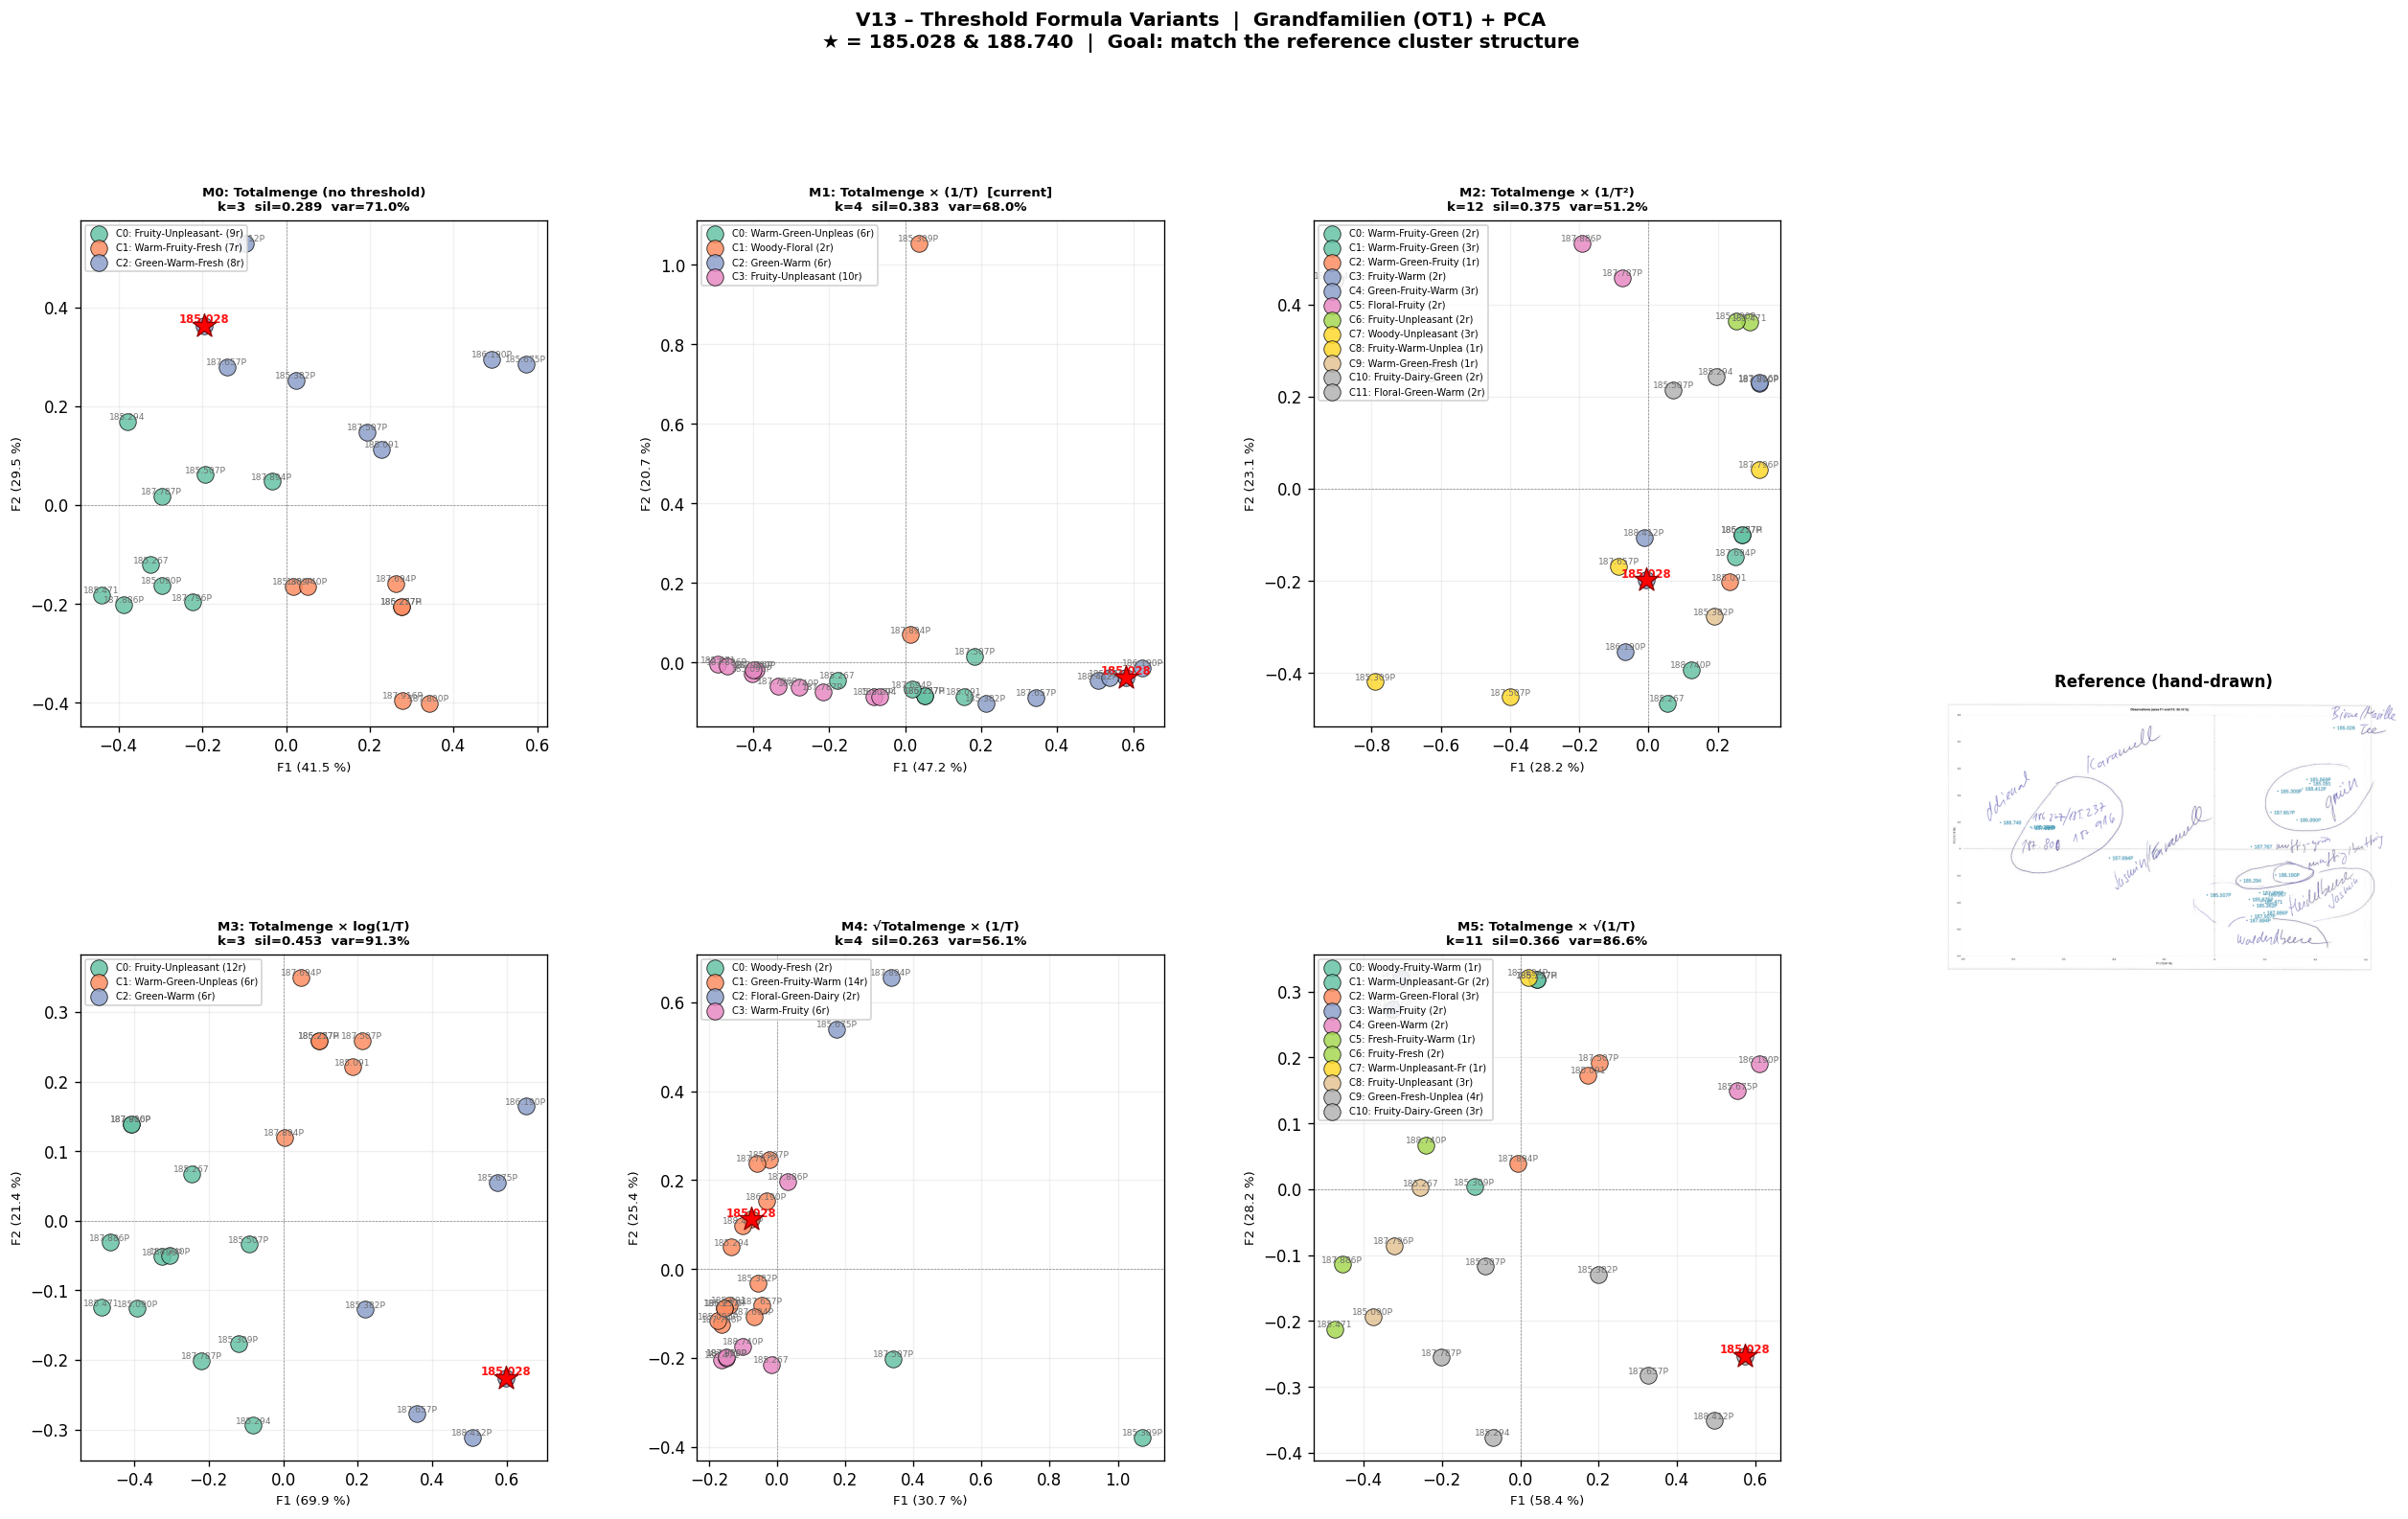

Saved → ../outputs/v13_threshold_variants_comparison.png


In [7]:
def plot_pca_variant(ax, res, recipes, title=None):
    """Plot a single PCA scatter on the given axes."""
    coords  = res['pca_coords']
    labels  = res['labels']
    cnames  = res['cnames']
    ve      = res['var_expl']
    unique_labels = sorted(set(labels))
    palette = plt.cm.Set2(np.linspace(0, 1, max(len(unique_labels), 8)))

    for j, cl in enumerate(unique_labels):
        mask = labels == cl
        pts  = coords[mask]
        c    = palette[j % len(palette)]
        ax.scatter(pts[:, 0], pts[:, 1], c=[c], s=110, alpha=0.85,
                   edgecolors='black', lw=0.5,
                   label=f'C{cl}: {cnames.get(cl, "")[:18]} ({mask.sum()}r)')

    for i, rec in enumerate(recipes):
        is_out = rec in OUTLIER_RECIPES
        ax.annotate(
            rec, (coords[i, 0], coords[i, 1]),
            fontsize=7 if is_out else 5.5,
            fontweight='bold' if is_out else 'normal',
            color='red' if is_out else 'dimgray',
            ha='center', va='bottom', alpha=0.92
        )
        if is_out:
            ax.scatter(coords[i, 0], coords[i, 1],
                       marker='*', s=240, c='red', zorder=5,
                       edgecolors='darkred', lw=0.8)

    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.axvline(0, color='gray', lw=0.4, ls='--')
    ax.set_xlabel(f'F1 ({ve[0]:.1f} %)', fontsize=8)
    ax.set_ylabel(f'F2 ({ve[1]:.1f} %)', fontsize=8)
    t = title or res['label']
    ax.set_title(f'{t}\nk={res["k"]}  sil={res["score"]:.3f}  '
                 f'var={sum(ve):.1f}%', fontsize=8, fontweight='bold')
    ax.legend(loc='upper left', fontsize=6, framealpha=0.85)
    ax.grid(True, alpha=0.18)


# ── Main figure: 2 rows × 4 cols (6 variants + reference + blank)
fig = plt.figure(figsize=(26, 14))
# We want: row0 = M0 M1 M2 | row1 = M3 M4 M5 | + reference on the right side
# Use gridspec: 2 rows, 4 cols; last col spans both rows for reference
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.32, hspace=0.45)

variant_ids = ['M0', 'M1', 'M2', 'M3', 'M4', 'M5']
positions   = [(0,0), (0,1), (0,2), (1,0), (1,1), (1,2)]

for vid, (row, col) in zip(variant_ids, positions):
    ax = fig.add_subplot(gs[row, col])
    plot_pca_variant(ax, results[vid], recipes)

# Reference image – spans both rows in col 3
ax_ref = fig.add_subplot(gs[:, 3])
if os.path.exists(REFERENCE_IMG):
    img = mpimg.imread(REFERENCE_IMG)
    ax_ref.imshow(img)
    ax_ref.set_title('Reference (hand-drawn)', fontsize=10, fontweight='bold')
else:
    ax_ref.text(0.5, 0.5, 'Reference image\nnot found',
                ha='center', va='center', transform=ax_ref.transAxes)
ax_ref.axis('off')

fig.suptitle(
    'V13 – Threshold Formula Variants  |  Grandfamilien (OT1) + PCA\n'
    '★ = 185.028 & 188.740  |  Goal: match the reference cluster structure',
    fontsize=12, fontweight='bold', y=1.01
)

out_path = f'{OUTPUT_DIR}/v13_threshold_variants_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 6. Metrics Summary Table

In [8]:
print(f'{"Variant":<40} {"k":>4} {"Silhouette":>12} {"PCA F1%":>9} {"PCA F2%":>9} {"Total var%":>11}')
print('-' * 90)
for vid in variant_ids:
    r  = results[vid]
    ve = r['var_expl']
    print(f'{r["label"]:<40} {r["k"]:>4} {r["score"]:>12.4f} '
          f'{ve[0]:>9.1f} {ve[1]:>9.1f} {sum(ve):>11.1f}')

print()
print('Note: Higher silhouette = tighter, better-separated clusters.')
print('      More variance explained = PCA axes are more informative.')
print()

# Show where the outlier recipes land in each variant
print('Outlier recipe positions across variants:')
print(f'{"Variant":<8} ', end='')
for rec in OUTLIER_RECIPES:
    print(f'{rec:>30}', end='')
print()
for vid in variant_ids:
    r      = results[vid]
    coords = r['pca_coords']
    labels = r['labels']
    cnames = r['cnames']
    print(f'{vid:<8} ', end='')
    for rec in OUTLIER_RECIPES:
        if rec in recipes:
            idx = recipes.index(rec)
            cl  = labels[idx]
            pos = coords[idx]
            print(f'  C{cl}({cnames[cl][:12]}) F1={pos[0]:+.2f} F2={pos[1]:+.2f}', end='')
        else:
            print(f'  NOT FOUND', end='')
    print()

Variant                                     k   Silhouette   PCA F1%   PCA F2%  Total var%
------------------------------------------------------------------------------------------
M0: Totalmenge (no threshold)               3       0.2893      41.5      29.5        71.0
M1: Totalmenge × (1/T)  [current]           4       0.3829      47.2      20.7        68.0
M2: Totalmenge × (1/T²)                    12       0.3751      28.2      23.1        51.2
M3: Totalmenge × log(1/T)                   3       0.4527      69.9      21.4        91.3
M4: √Totalmenge × (1/T)                     4       0.2627      30.7      25.4        56.1
M5: Totalmenge × √(1/T)                    11       0.3657      58.4      28.2        86.6

Note: Higher silhouette = tighter, better-separated clusters.
      More variance explained = PCA axes are more informative.

Outlier recipe positions across variants:
Variant                         185.028                       188.740
M0         C2(Green-Warm-F) F1=-0

## 7. Side-by-Side: Best Variant vs Reference
Pick the variant whose PCA cluster separation looks closest to the reference and show it large.

In [9]:
# Rank variants by silhouette score
ranked = sorted(variant_ids, key=lambda vid: results[vid]['score'], reverse=True)
best_vid = ranked[0]
print(f'Best by silhouette: {best_vid} — {results[best_vid]["label"]}')
print(f'Ranked: {ranked}')
print()
print('(Visual inspection may differ — compare the plot above with the reference)')

Best by silhouette: M3 — M3: Totalmenge × log(1/T)
Ranked: ['M3', 'M1', 'M2', 'M5', 'M0', 'M4']

(Visual inspection may differ — compare the plot above with the reference)


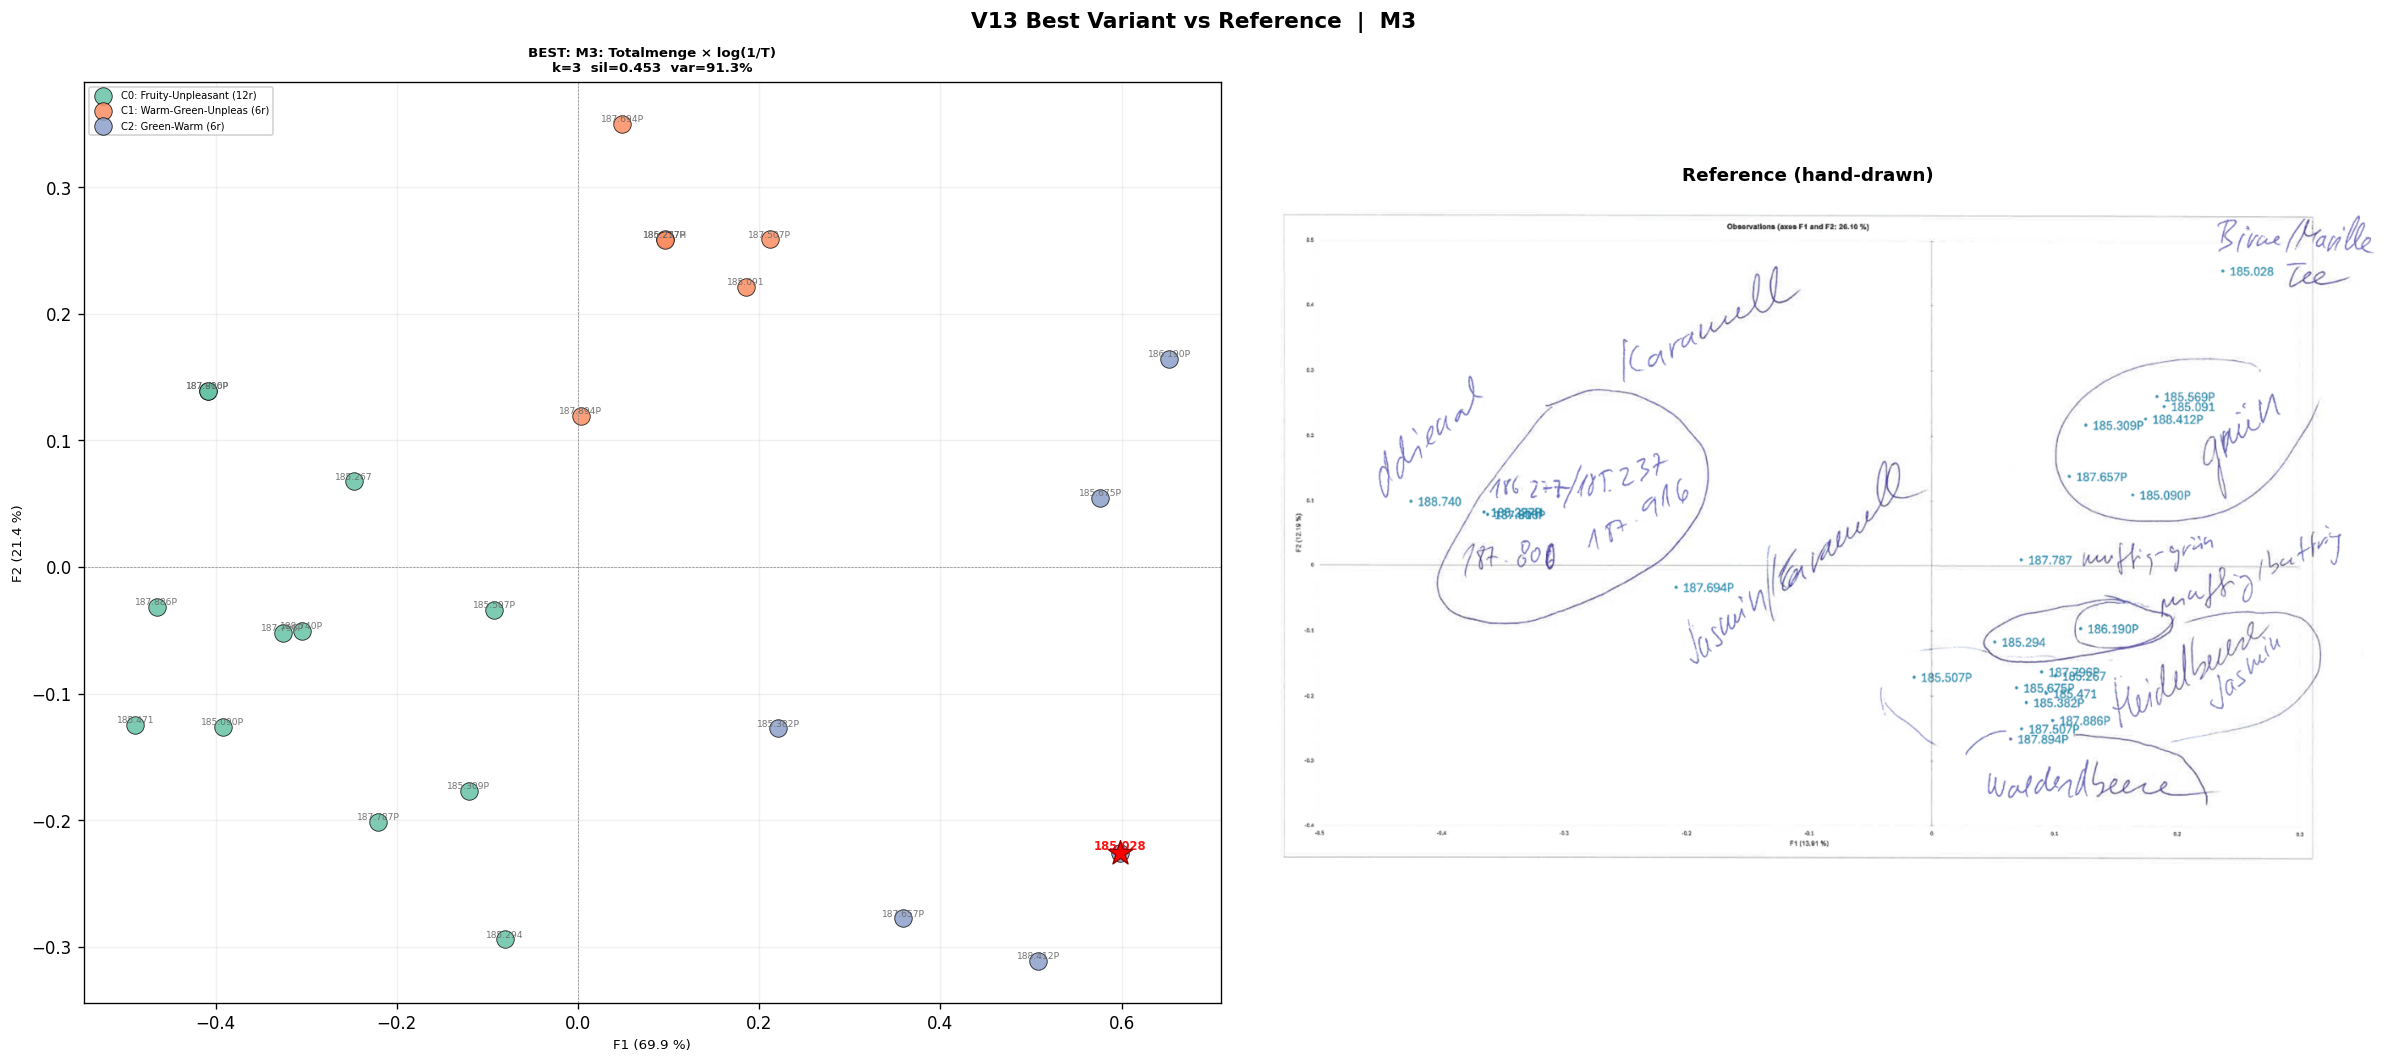

Saved → ../outputs/v13_best_vs_reference.png


In [10]:
# Large side-by-side: best variant vs reference
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

plot_pca_variant(axes[0], results[best_vid], recipes,
                 title=f'BEST: {results[best_vid]["label"]}')

if os.path.exists(REFERENCE_IMG):
    img = mpimg.imread(REFERENCE_IMG)
    axes[1].imshow(img)
    axes[1].set_title('Reference (hand-drawn)', fontsize=11, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Reference image not found',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].axis('off')

plt.suptitle(f'V13 Best Variant vs Reference  |  {best_vid}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path2 = f'{OUTPUT_DIR}/v13_best_vs_reference.png'
plt.savefig(out_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path2}')

## 8. Verdict

| Variant | Formula | Hypothesis |
|---------|---------|----------|
| M0 | `qty` | No threshold – pure quantity → V9 winner |
| M1 | `qty × 1/T` | Linear potency – amplifies trace-but-potent ingredients |
| M2 | `qty × 1/T²` | Quadratic – extremises potency differences |
| M3 | `qty × log(1/T)` | Log-scale – gentle, robust to outlier thresholds |
| M4 | `√qty × 1/T` | Dampens quantity dominance |
| M5 | `qty × √(1/T)` | Halves the exponent on threshold |

**Visual match criteria vs reference:**
- Caramel/Süß cluster in upper-left quadrant
- Fruchtig/Beere group separated in lower-right
- 185.028 (Birne/Marille/Tee) isolated in upper-right
- 188.740 (Addierand) isolated in left
- Jasmin/Karamell bridge in centre